### Implementing Scaled Dot-Product Attention: $softmax(\frac{QK^T}{\sqrt d_k})V$


In [13]:
import torch
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [14]:
def scaled_dot_product_attention(query, key, value, mask=None):
    """
    Computes Scaled Dot-Product Attention.

    Args:
        query: Query tensor; shape (batch_size, seq_len_q, d_k)
        key: Tensor; shape (batch_size, seq_len_k, d_k)
        value: Value tensor; shape (batch_size, seq_len_k, d_v)
               Note: seq_len_k must match between key and value.
               d_v (value dimension) can differ from d_k (query dimension).
        mask: Optional mask tensor; shape broadcastable to (batch_size, seq_len_q, seq_len_k).
              Positions with True or 1 indicate values to keep, False or 0 to mask out.

    Returns:
        output: The attention output tensor; shape (batch_size, seq_len_q, d_v)
        attention_weights: The attention weights; shape (batch_size, seq_len_q, seq_len_k)
    """

    #dimension of key
    d_k = key.size(-1)

    # 1. QK^T: (batch_size, seq_len_q, d_k) @ (batch_size, d_k, seq_len_k) -> (batch_size, seq_len_q, seq_len_k)
    scores = torch.matmul(query, key.transpose(-2,-1))

    # 2. Scale by sqrt(d_k)
    scaled_scores = scores / math.sqrt(d_k)

    # 3. Apply mask if provided
    # if mask position is 0, set the scaled_scores to -inf so that the softmax of it can be 0
    if mask is not None:
        scaled_scores = scaled_scores.masked_fill(mask == 0, -1e9)

    # 4. Softmax is applied on the last dimension (seq_len_k)
    attention_weights = F.softmax(scaled_scores, dim = -1)

    # Replace NaN with 0 to handle potential NaN from softmax if all scores in a row are -inf
    # This can happen if a query position is masked entirely against all keys.
    attention_weights = torch.nan_to_num(attention_weights)

    # 5. Multiply weights by V
    # (batch_size, seq_len_q, seq_len_k) @ (batch_size, seq_len_k, d_v) -> (batch_size, seq_len_q, d_v)
    outputs = torch.matmul(attention_weights, value)
    
    return outputs, attention_weights

#### Test code

In [15]:
batch_size = 1
seq_len_q = 3 # Sequence length for queries
seq_len_k = 4 # Sequence length for keys/values
d_k = 4      # Dimension of keys/queries
d_v = 4      # Dimension of values

# Generate random tensors
query = torch.randn(batch_size, seq_len_q, d_k)
key = torch.randn(batch_size, seq_len_k, d_k)
value = torch.randn(batch_size, seq_len_k, d_v)

# no mask
output, attention_weights = scaled_dot_product_attention(query, key, value)
print("--- Output without Mask ---")
print("Output shape:", output.shape) # Expected: [1, 3, 16]
print("Attention weights shape:", attention_weights.shape) # Expected: [1, 3, 4]
# Each row in attention_weights should sum to 1
print("Attention weights sum (second query):", attention_weights[0, 1, :].sum())

# with mask
# Create a sample mask. Let's mask out the last position for all queries.
# Mask shape: (batch_size, seq_len_q, seq_len_k)
# Here, simpler: (batch_size, 1, seq_len_k) broadcastable
mask = torch.ones(batch_size, 1, seq_len_k, dtype=torch.bool)
mask[:, :, -1] = 0 # Mask the last position (index 3)
# we mask it out for all query tokens and all attention heads at last position of each query

print("\nMask shape:", mask.shape)
print("Mask content:\n", mask)

output_masked, attention_weights_masked = scaled_dot_product_attention(query, key, value, mask=mask)

print("\n--- Output with Mask ---")
print("Output shape:", output_masked.shape) # Expected: [1, 3, 16]
print("Attention weights shape:", attention_weights_masked.shape) # Expected: [1, 3, 4]
print("Masked Attention weights (first query):\n", attention_weights_masked[0, 0, :])
# Note that the weight for the last position (index 3) should be 0 or very close to it.
print("Attention weights sum (first query, masked):", attention_weights_masked[0, 0, :].sum())

--- Output without Mask ---
Output shape: torch.Size([1, 3, 4])
Attention weights shape: torch.Size([1, 3, 4])
Attention weights sum (second query): tensor(1.)

Mask shape: torch.Size([1, 1, 4])
Mask content:
 tensor([[[ True,  True,  True, False]]])

--- Output with Mask ---
Output shape: torch.Size([1, 3, 4])
Attention weights shape: torch.Size([1, 3, 4])
Masked Attention weights (first query):
 tensor([0.4545, 0.1170, 0.4285, 0.0000])
Attention weights sum (first query, masked): tensor(1.)


#### Visualizations

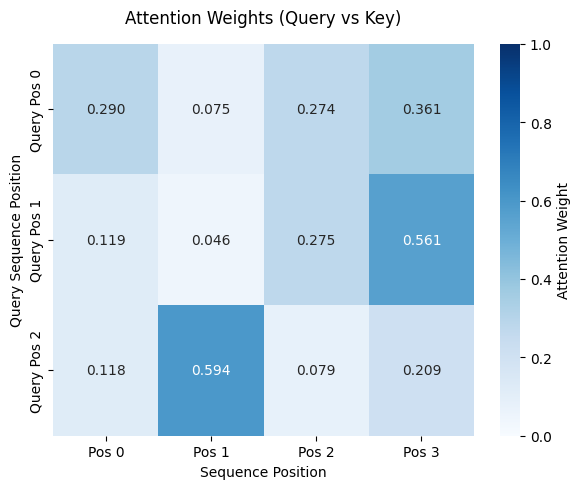

In [16]:
weights_np = attention_weights[0].detach().numpy()

plt.figure(figsize=(6, 5))
sns.heatmap(
    weights_np, 
    annot=True,              # Display weight values inside cells
    fmt=".3f",               # Format to 3 decimal places
    cmap="Blues",            # Match the blue color scale
    xticklabels=[f'Pos {i}' for i in range(seq_len_k)],
    yticklabels=[f'Query Pos {i}' for i in range(seq_len_q)],
    vmin=0, 
    vmax=1,
    cbar_kws={'label': 'Attention Weight'}
)
plt.title("Attention Weights (Query vs Key)", pad=15, fontsize=12)
plt.xlabel("Sequence Position", fontsize=10)
plt.ylabel("Query Sequence Position", fontsize=10)
plt.tight_layout()
plt.show()